<a href="https://colab.research.google.com/github/NamNam9252/Deep-Learning/blob/main/Linear_Regression_Gradeint_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

Epoch 01/40 | Loss: 0.6931 | w1: +0.004 | w2: +0.046 | b: +0.000 | Accuracy: 50.0%
Epoch 02/40 | Loss: 0.6725 | w1: +0.008 | w2: +0.090 | b: +0.000 | Accuracy: 98.0%
Epoch 03/40 | Loss: 0.6530 | w1: +0.011 | w2: +0.133 | b: +0.000 | Accuracy: 98.0%
Epoch 04/40 | Loss: 0.6345 | w1: +0.013 | w2: +0.175 | b: +0.000 | Accuracy: 98.0%
Epoch 05/40 | Loss: 0.6169 | w1: +0.015 | w2: +0.216 | b: +0.000 | Accuracy: 98.0%
Epoch 06/40 | Loss: 0.6003 | w1: +0.016 | w2: +0.256 | b: +0.000 | Accuracy: 98.0%
Epoch 07/40 | Loss: 0.5844 | w1: +0.017 | w2: +0.295 | b: +0.000 | Accuracy: 98.0%
Epoch 08/40 | Loss: 0.5694 | w1: +0.017 | w2: +0.333 | b: +0.000 | Accuracy: 98.0%
Epoch 09/40 | Loss: 0.5551 | w1: +0.017 | w2: +0.370 | b: +0.000 | Accuracy: 98.0%
Epoch 10/40 | Loss: 0.5414 | w1: +0.017 | w2: +0.407 | b: +0.000 | Accuracy: 98.0%
Epoch 11/40 | Loss: 0.5284 | w1: +0.016 | w2: +0.442 | b: +0.000 | Accuracy: 98.0%
Epoch 12/40 | Loss: 0.5160 | w1: +0.014 | w2: +0.477 | b: +0.000 | Accuracy: 98.0%
Epoc

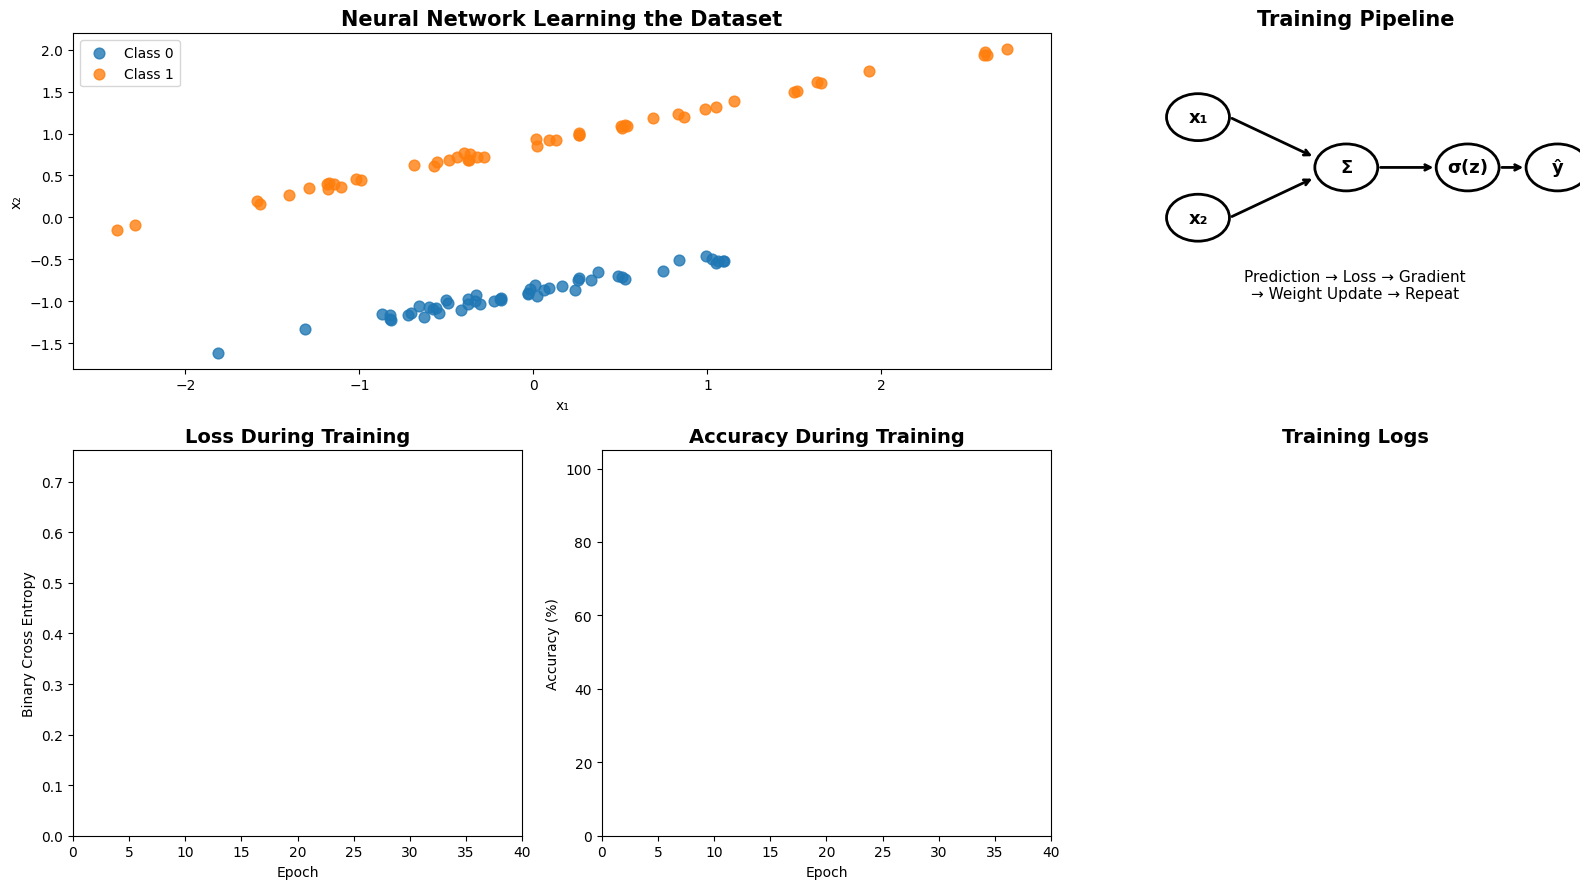


TRAINING COMPLETE
Final w1       : -0.0944
Final w2       : 1.2144
Final bias     : 0.0067
Final loss     : 0.3074
Final accuracy : 100.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from matplotlib.animation import FuncAnimation

# ============================================================
# 1. CREATE DATASET
# ============================================================

np.random.seed(42)

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Standardize manually
X = (X - X.mean(axis=0)) / X.std(axis=0)

# ============================================================
# 2. INITIALIZE PERCEPTRON
# ============================================================

w = np.array([0.0, 0.0])
b = 0.0

learning_rate = 0.1
epochs = 40

# Store training history
loss_history = []
weight_history = []
bias_history = []
accuracy_history = []

# ============================================================
# 3. ACTIVATION FUNCTION
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# ============================================================
# 4. LOSS FUNCTION
# ============================================================

def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-8

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_pred)
        +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss


# ============================================================
# 5. TRAINING
# ============================================================

training_logs = []

for epoch in range(epochs):

    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    z = np.dot(X, w) + b

    predictions = sigmoid(z)

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    loss = binary_cross_entropy(y, predictions)

    # --------------------------------------------------------
    # GRADIENT
    # --------------------------------------------------------

    error = predictions - y

    dw = np.dot(X.T, error) / len(X)

    db = np.mean(error)

    # --------------------------------------------------------
    # UPDATE
    # --------------------------------------------------------

    w = w - learning_rate * dw

    b = b - learning_rate * db

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    predicted_classes = (predictions >= 0.5).astype(int)

    accuracy = np.mean(
        predicted_classes == y
    ) * 100

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    loss_history.append(loss)
    weight_history.append(w.copy())
    bias_history.append(b)
    accuracy_history.append(accuracy)

    # --------------------------------------------------------
    # LOG
    # --------------------------------------------------------

    log = (
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Loss: {loss:.4f} | "
        f"w1: {w[0]:+.3f} | "
        f"w2: {w[1]:+.3f} | "
        f"b: {b:+.3f} | "
        f"Accuracy: {accuracy:.1f}%"
    )

    training_logs.append(log)

    print(log)


# ============================================================
# 6. VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(16, 9))

gs = fig.add_gridspec(
    2,
    3,
    height_ratios=[1, 1.15]
)

# ------------------------------------------------------------
# AXIS 1: DATASET + DECISION BOUNDARY
# ------------------------------------------------------------

ax_dataset = fig.add_subplot(gs[0, 0:2])

ax_dataset.set_title(
    "Neural Network Learning the Dataset",
    fontsize=15,
    fontweight="bold"
)

ax_dataset.set_xlabel("x₁")
ax_dataset.set_ylabel("x₂")

ax_dataset.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    s=60,
    alpha=0.8
)

ax_dataset.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    s=60,
    alpha=0.8
)

ax_dataset.legend()

# ------------------------------------------------------------
# DECISION BOUNDARY
# ------------------------------------------------------------

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

x_values = np.linspace(
    x_min,
    x_max,
    200
)

boundary_line, = ax_dataset.plot(
    [],
    [],
    linewidth=3,
    label="Decision Boundary"
)

# ------------------------------------------------------------
# AXIS 2: NETWORK PIPELINE
# ------------------------------------------------------------

ax_network = fig.add_subplot(gs[0, 2])

ax_network.axis("off")

ax_network.set_title(
    "Training Pipeline",
    fontsize=15,
    fontweight="bold"
)

# Nodes
nodes = [
    ("x₁", 0.15, 0.75),
    ("x₂", 0.15, 0.45),

    ("Σ", 0.48, 0.60),

    ("σ(z)", 0.75, 0.60),

    ("ŷ", 0.95, 0.60),
]

for text, x, y_pos in nodes:

    circle = plt.Circle(
        (x, y_pos),
        0.07,
        fill=False,
        linewidth=2
    )

    ax_network.add_patch(circle)

    ax_network.text(
        x,
        y_pos,
        text,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


# Connections

connections = [
    ((0.22, 0.75), (0.41, 0.63)),
    ((0.22, 0.45), (0.41, 0.57)),
    ((0.55, 0.60), (0.68, 0.60)),
    ((0.82, 0.60), (0.88, 0.60)),
]

for start, end in connections:

    ax_network.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2
        )
    )


# Training loop

ax_network.text(
    0.5,
    0.25,
    "Prediction → Loss → Gradient\n"
    "→ Weight Update → Repeat",
    ha="center",
    va="center",
    fontsize=11
)

# ------------------------------------------------------------
# AXIS 3: LOSS
# ------------------------------------------------------------

ax_loss = fig.add_subplot(gs[1, 0])

ax_loss.set_title(
    "Loss During Training",
    fontsize=14,
    fontweight="bold"
)

ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Binary Cross Entropy")

ax_loss.set_xlim(0, epochs)

ax_loss.set_ylim(
    0,
    max(loss_history) * 1.1
)

loss_line, = ax_loss.plot(
    [],
    [],
    linewidth=3
)

# ------------------------------------------------------------
# AXIS 4: ACCURACY
# ------------------------------------------------------------

ax_accuracy = fig.add_subplot(gs[1, 1])

ax_accuracy.set_title(
    "Accuracy During Training",
    fontsize=14,
    fontweight="bold"
)

ax_accuracy.set_xlabel("Epoch")
ax_accuracy.set_ylabel("Accuracy (%)")

ax_accuracy.set_xlim(0, epochs)

ax_accuracy.set_ylim(
    0,
    105
)

accuracy_line, = ax_accuracy.plot(
    [],
    [],
    linewidth=3
)

# ------------------------------------------------------------
# AXIS 5: LIVE LOG
# ------------------------------------------------------------

ax_log = fig.add_subplot(gs[1, 2])

ax_log.axis("off")

ax_log.set_title(
    "Training Logs",
    fontsize=14,
    fontweight="bold"
)

log_text = ax_log.text(
    0.02,
    0.98,
    "",
    transform=ax_log.transAxes,
    verticalalignment="top",
    family="monospace",
    fontsize=9
)


# ============================================================
# 7. ANIMATION
# ============================================================

def update(frame):

    epoch = frame + 1

    # --------------------------------------------------------
    # DECISION BOUNDARY
    # --------------------------------------------------------

    current_w = weight_history[frame]
    current_b = bias_history[frame]

    if abs(current_w[1]) > 1e-8:

        y_values = (
            -(current_w[0] * x_values + current_b)
            / current_w[1]
        )

        boundary_line.set_data(
            x_values,
            y_values
        )

    # --------------------------------------------------------
    # LOSS GRAPH
    # --------------------------------------------------------

    epochs_x = np.arange(
        1,
        epoch + 1
    )

    loss_line.set_data(
        epochs_x,
        loss_history[:epoch]
    )

    # --------------------------------------------------------
    # ACCURACY GRAPH
    # --------------------------------------------------------

    accuracy_line.set_data(
        epochs_x,
        accuracy_history[:epoch]
    )

    # --------------------------------------------------------
    # LOGS
    # --------------------------------------------------------

    recent_logs = training_logs[
        max(0, epoch - 8):epoch
    ]

    log_text.set_text(
        "\n".join(recent_logs)
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    fig.suptitle(
        f"Neural Network Training Pipeline  |  "
        f"Epoch {epoch}/{epochs}",
        fontsize=18,
        fontweight="bold"
    )

    return (
        boundary_line,
        loss_line,
        accuracy_line,
        log_text
    )


# ============================================================
# 8. CREATE ANIMATION
# ============================================================

animation = FuncAnimation(
    fig,
    update,
    frames=epochs,
    interval=500,
    repeat=False
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. FINAL RESULT
# ============================================================

final_predictions = (
    sigmoid(np.dot(X, w) + b) >= 0.5
).astype(int)

final_accuracy = (
    np.mean(final_predictions == y)
    * 100
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"Final w1       : {w[0]:.4f}")
print(f"Final w2       : {w[1]:.4f}")
print(f"Final bias     : {b:.4f}")
print(f"Final loss     : {loss_history[-1]:.4f}")
print(f"Final accuracy : {final_accuracy:.2f}%")

print("=" * 70)

IntSlider(value=8, continuous_update=False, description='Neurons:', max=32, min=1)

Dropdown(description='Activation:', index=3, options=('relu', 'sigmoid', 'tanh', 'linear'), value='linear')

FloatLogSlider(value=0.01, continuous_update=False, description='Learning rate:', max=-0.5, min=-4.0, step=0.0…

IntSlider(value=50, continuous_update=False, description='Epochs:', max=200, min=10, step=10)

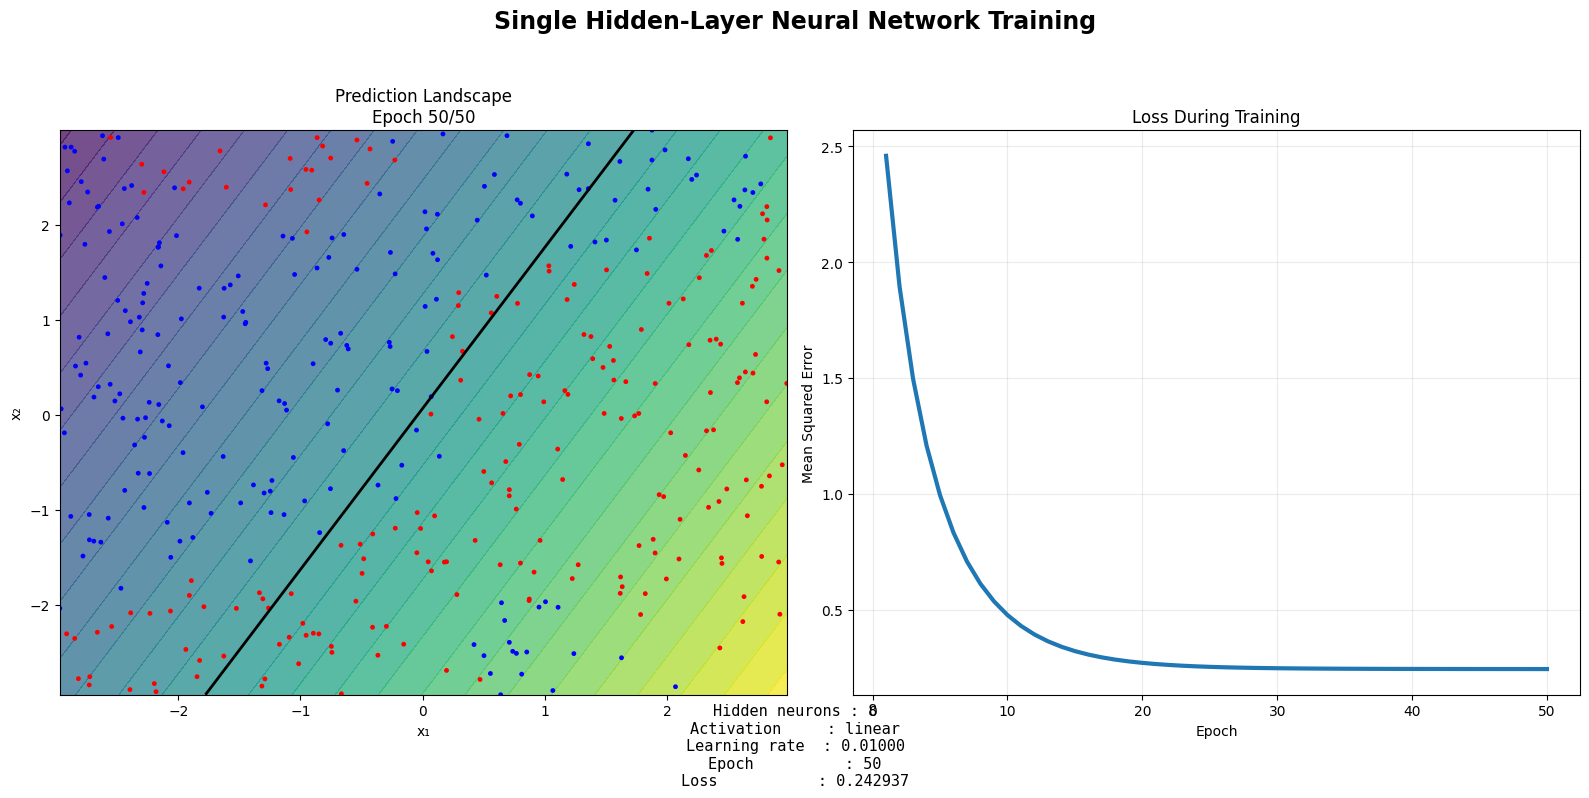

Epoch 050/50 | Loss = 0.242937


In [1]:
!pip install ipywidgets tensorflow

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

print("TensorFlow version:", tf.__version__)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


# ================================================================
# 2. CREATE A 2D REGRESSION DATASET
# ================================================================

# Two-dimensional input
X = np.random.uniform(-3, 3, (400, 2)).astype(np.float32)

x1 = X[:, 0]
x2 = X[:, 1]

# Non-linear target function
y = (
    np.sin(x1)
    * np.cos(x2)
    + 0.15 * x1
    - 0.1 * x2
)

# Add noise
y += 0.08 * np.random.randn(len(y))

y = y.astype(np.float32)

# Convert to TensorFlow tensors
X_tf = tf.constant(X)
y_tf = tf.constant(y.reshape(-1, 1))

print("Dataset shape:", X.shape)
print("Target shape :", y.shape)


# ================================================================
# 3. VISUALIZE DATASET
# ================================================================

fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    y,
    c=y,
    cmap="viridis",
    s=20
)

ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_zlabel("Target y")

ax.set_title("2D Regression Dataset")

plt.show()


# ================================================================
# 4. INTERACTIVE CONTROLS
# ================================================================

neurons_slider = widgets.IntSlider(
    value=8,
    min=1,
    max=32,
    step=1,
    description="Neurons:",
    continuous_update=False
)

activation_dropdown = widgets.Dropdown(
    options=[
        "relu",
        "sigmoid",
        "tanh",
        "linear"
    ],
    value="relu",
    description="Activation:"
)

learning_rate_slider = widgets.FloatLogSlider(
    value=0.01,
    base=10,
    min=-4,
    max=-0.5,
    step=0.05,
    description="Learning rate:",
    continuous_update=False
)

epochs_slider = widgets.IntSlider(
    value=50,
    min=10,
    max=200,
    step=10,
    description="Epochs:",
    continuous_update=False
)

train_button = widgets.Button(
    description="Train Network",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(
    neurons_slider,
    activation_dropdown,
    learning_rate_slider,
    epochs_slider,
    widgets.HBox([
        train_button,
        reset_button
    ])
)


# ================================================================
# 5. ACTIVATION FUNCTION
# ================================================================

def get_activation(name):

    if name == "relu":
        return tf.nn.relu

    elif name == "sigmoid":
        return tf.nn.sigmoid

    elif name == "tanh":
        return tf.nn.tanh

    elif name == "linear":
        return tf.identity


# ================================================================
# 6. BUILD NETWORK
# ================================================================

def build_network(num_neurons, activation_name):

    activation = get_activation(activation_name)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),

        tf.keras.layers.Dense(
            num_neurons,
            activation=activation
        ),

        # Regression output
        tf.keras.layers.Dense(
            1,
            activation=None
        )
    ])

    return model


# ================================================================
# 7. GLOBAL VARIABLES
# ================================================================

model = None

loss_history = []

trained = False


# ================================================================
# 8. TRAINING FUNCTION
# ================================================================

def train_network():

    global model
    global loss_history
    global trained

    num_neurons = neurons_slider.value
    activation_name = activation_dropdown.value
    learning_rate = learning_rate_slider.value
    epochs = epochs_slider.value

    # --------------------------------------------
    # Build new model
    # --------------------------------------------

    model = build_network(
        num_neurons,
        activation_name
    )

    # Initialize weights
    dummy = tf.zeros((1, 2))
    model(dummy)

    loss_history = []

    trained = True

    # --------------------------------------------
    # Training
    # --------------------------------------------

    for epoch in range(epochs):

        # ========================================
        # FORWARD PASS
        # ========================================

        with tf.GradientTape() as tape:

            predictions = model(X_tf)

            # Mean Squared Error
            loss = tf.reduce_mean(
                tf.square(
                    y_tf - predictions
                )
            )

        # ========================================
        # BACKPROPAGATION
        # ========================================

        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )

        # ========================================
        # GRADIENT DESCENT
        # ========================================

        for variable, gradient in zip(
            model.trainable_variables,
            gradients
        ):

            variable.assign_sub(
                learning_rate * gradient
            )

        loss_history.append(
            float(loss.numpy())
        )

        # ========================================
        # DYNAMIC VISUALIZATION
        # ========================================

        clear_output(wait=True)

        display(
            neurons_slider,
            activation_dropdown,
            learning_rate_slider,
            epochs_slider,
            widgets.HBox([
                train_button,
                reset_button
            ])
        )

        # ------------------------------------------------
        # Create figure
        # ------------------------------------------------

        fig = plt.figure(figsize=(16, 8))

        # =================================================
        # LEFT: PREDICTION CONTOUR
        # =================================================

        ax1 = fig.add_subplot(121)

        # Grid
        grid_size = 80

        gx = np.linspace(
            X[:, 0].min(),
            X[:, 0].max(),
            grid_size
        )

        gy = np.linspace(
            X[:, 1].min(),
            X[:, 1].max(),
            grid_size
        )

        GX, GY = np.meshgrid(gx, gy)

        grid_points = np.column_stack([
            GX.ravel(),
            GY.ravel()
        ]).astype(np.float32)

        grid_tf = tf.constant(grid_points)

        # Prediction
        grid_prediction = model(
            grid_tf,
            training=False
        ).numpy()

        GZ = grid_prediction.reshape(
            GX.shape
        )

        # Prediction surface
        contour = ax1.contourf(
            GX,
            GY,
            GZ,
            levels=30,
            cmap="viridis",
            alpha=0.75
        )

        # Actual data
        ax1.scatter(
            X[y < 0, 0],
            X[y < 0, 1],
            c="blue",
            s=12,
            edgecolors="none"
        )

        ax1.scatter(
            X[y >= 0, 0],
            X[y >= 0, 1],
            c="red",
            s=12,
            edgecolors="none"
        )

        # ------------------------------------------------
        # Zero contour
        # ------------------------------------------------

        ax1.contour(
            GX,
            GY,
            GZ,
            levels=[0],
            colors="black",
            linewidths=2
        )

        ax1.set_xlabel("x₁")
        ax1.set_ylabel("x₂")

        ax1.set_title(
            f"Prediction Landscape\n"
            f"Epoch {epoch + 1}/{epochs}"
        )

        # =================================================
        # RIGHT: LOSS
        # =================================================

        ax2 = fig.add_subplot(122)

        ax2.plot(
            range(1, epoch + 2),
            loss_history,
            linewidth=3
        )

        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Mean Squared Error")

        ax2.set_title(
            "Loss During Training"
        )

        ax2.grid(True, alpha=0.25)

        # ------------------------------------------------
        # Training information
        # ------------------------------------------------

        fig.suptitle(
            "Single Hidden-Layer Neural Network Training",
            fontsize=17,
            fontweight="bold"
        )

        info = (
            f"Hidden neurons : {num_neurons}\n"
            f"Activation     : {activation_name}\n"
            f"Learning rate  : {learning_rate:.5f}\n"
            f"Epoch          : {epoch + 1}\n"
            f"Loss           : {loss.numpy():.6f}"
        )

        fig.text(
            0.5,
            0.01,
            info,
            ha="center",
            fontsize=11,
            family="monospace"
        )

        plt.tight_layout(
            rect=[0, 0.05, 1, 0.95]
        )

        plt.show()

        # ------------------------------------------------
        # Console log
        # ------------------------------------------------

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Loss = {loss.numpy():.6f}"
        )


# ================================================================
# 9. BUTTON CALLBACKS
# ================================================================

def train_button_clicked(button):

    train_network()


def reset_button_clicked(button):

    global model
    global loss_history
    global trained

    model = None
    loss_history = []
    trained = False

    clear_output(wait=True)

    display(
        neurons_slider,
        activation_dropdown,
        learning_rate_slider,
        epochs_slider,
        widgets.HBox([
            train_button,
            reset_button
        ])
    )

    print("Network reset.")


train_button.on_click(
    train_button_clicked
)

reset_button.on_click(
    reset_button_clicked
)